# 🚀 Lab 48: Forecasting with ARIMA and SARIMA

## 🎯 Objectives
*   Understand the fundamentals of ARIMA and SARIMA models for time series forecasting
*   Apply the Augmented Dickey-Fuller (ADF) test to check for stationarity
*   Use differencing to make non-stationary data stationary
*   Use `auto_arima` for automatic parameter selection
*   Build, evaluate, and compare ARIMA and SARIMA models
*   Generate future forecasts with confidence intervals
*   Perform walk-forward validation and translate results into business insights.

## 🧰 Prerequisites
*   Basic Python programming
*   Familiarity with pandas, numpy, and matplotlib
*   Understanding of time series concepts (trend, seasonality, stationarity)

---

## ⚙️ Environment Setup

### ELI10
Before we can forecast anything, we need the right tools. These libraries help us handle data tables, perform complex math, create charts, and use specialized forecasting formulas.

**What we are doing:** Installing and importing libraries like `pmdarima` and `statsmodels`.
**Why:** These contain the statistical tests and models (like ARIMA) that we need.
**Result:** A working environment ready for data science.

In [1]:
# Install pmdarima for automatic model selection
!pip install -q pandas numpy matplotlib seaborn statsmodels pmdarima scikit-learn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

# Time series analysis tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Auto ARIMA
from pmdarima import auto_arima

# Metrics and Diagnostics
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Set seed for reproducibility
np.random.seed(42)
print("Environment Setup Complete.")

Environment Setup Complete.


## 📥 Creating the Datasets

### ELI10
We need some data to practice on. We are going to make a "fake" history of airline passengers that has a clear upward trend and a repeating seasonal pattern.

**What we are doing:** Generating synthetic time series data.
**Why:** This ensures we have a known pattern to test our models against.
**Result:** Two DataFrames: `df` (simple) and `airline_df` (realistic).

In [3]:
# 1. Create simple sample time series
dates = pd.date_range(start="2020-01-01", end="2023-12-01", freq="MS")
n = len(dates)
trend = np.linspace(100, 200, n)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 5, n)
ts_data = trend + seasonal + noise

df = pd.DataFrame({"date": dates, "value": ts_data}).set_index("date")

# 2. Create realistic airline passenger data
dates_airline = pd.date_range(start="2015-01-01", end="2023-12-01", freq="MS")
n_airline = len(dates_airline)
base_passengers = 100
trend_airline = np.linspace(0, 50, n_airline)
seasonal_airline = (20 * np.sin(2 * np.pi * np.arange(n_airline) / 12) + 10 * np.sin(4 * np.pi * np.arange(n_airline) / 12))
growth = np.exp(0.02 * np.arange(n_airline))
noise_airline = np.random.normal(0, 8, n_airline)

airline_data = (base_passengers + trend_airline + seasonal_airline) * growth + noise_airline
airline_df = pd.DataFrame({"date": dates_airline, "passengers": airline_data}).set_index("date")

print(f"Dataframes created. Airline shape: {airline_df.shape}")
display(airline_df.head())

Dataframes created. Airline shape: (108, 1)


,passengers
date,
2015-01-01,102.748946
2015-02-01,107.429759
2015-03-01,134.687527
2015-04-01,125.828283
2015-05-01,114.319708


## 🔍 Exploratory Data Analysis

### ELI10
Before using math, we use our eyes. We look at the data to see if it goes up, if it cycles, or if it is just a mess.

**What we are doing:** Plotting the data and decomposing it into trend, seasonality, and noise.
**Why:** To decide if we need a seasonal model (SARIMA) or a simple one (ARIMA).
**Result:** Visual confirmation of patterns.

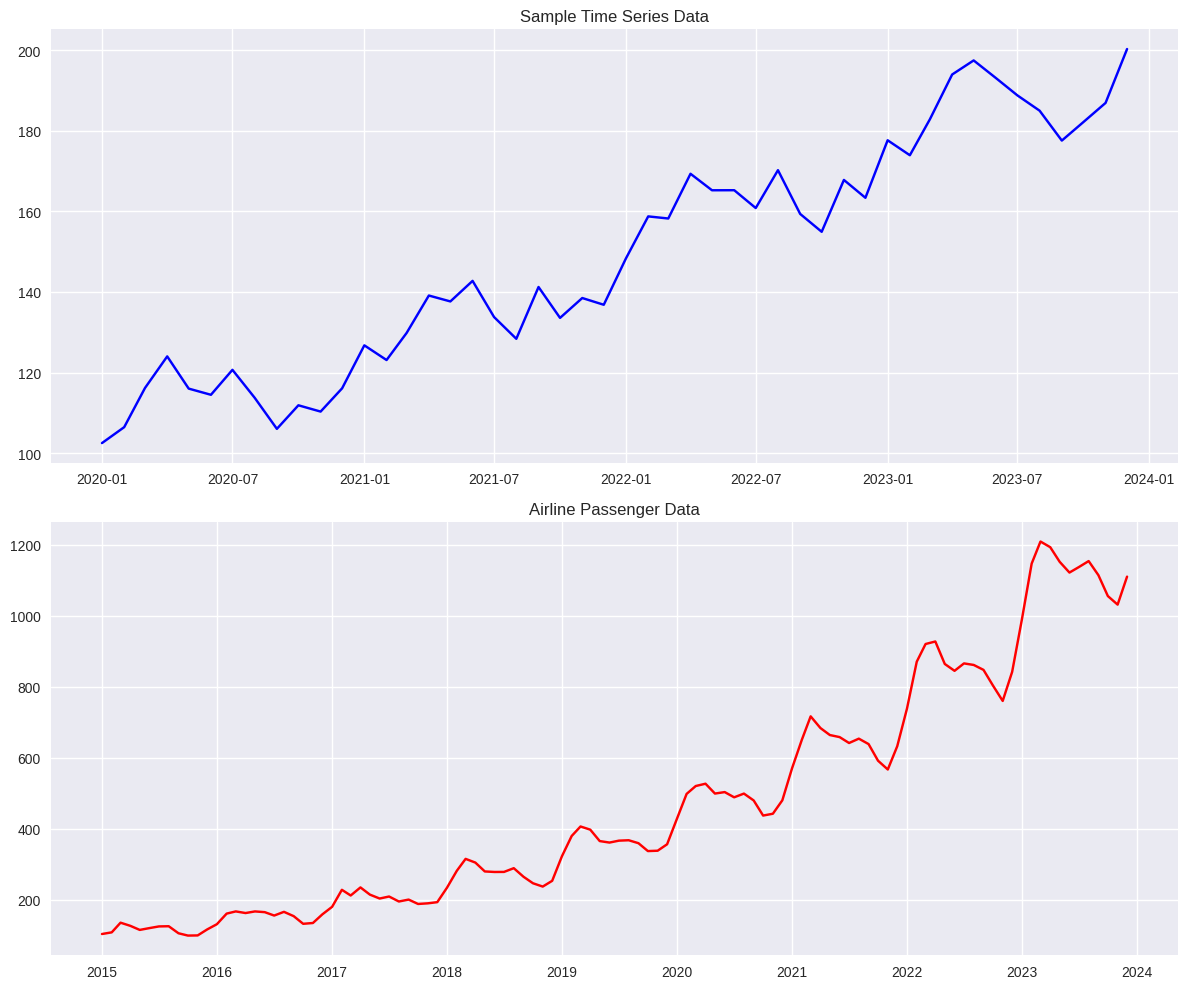

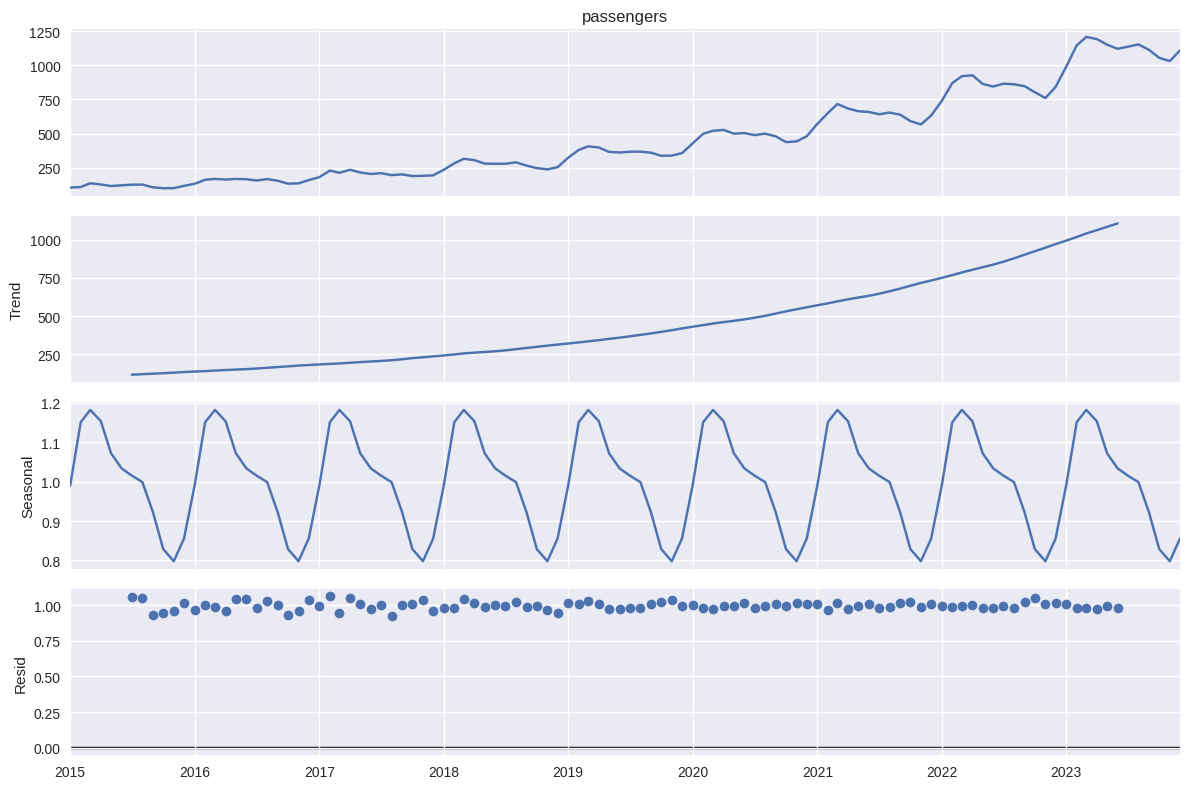

In [4]:
# Visualize both datasets
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].plot(df.index, df["value"], color="blue")
axes[0].set_title("Sample Time Series Data")
axes[1].plot(airline_df.index, airline_df["passengers"], color="red")
axes[1].set_title("Airline Passenger Data")
plt.tight_layout()
plt.show()

# Multiplicative Decomposition
decomposition = seasonal_decompose(airline_df["passengers"], model="multiplicative", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 🧪 Stationarity Testing

### ELI10
Stationarity means the data's "vibe" (average and spread) doesn't change over time. Models like ARIMA need this to be true to work correctly.

**What we are doing:** Running the Augmented Dickey-Fuller (ADF) test.
**Why:** If the p-value is > 0.05, the data isn't stationary and we must "fix" it.
**Result:** A statistical conclusion on data stability.

In [5]:
def check_stationarity(timeseries, title):
    print(f"\n--- ADF Test for {title} ---")
    result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Result: STATIONARY (Reject Null)")
        return True
    else:
        print("Result: NON-STATIONARY (Fail to Reject Null)")
        return False

is_stationary_sample = check_stationarity(df["value"], "Sample Data")
is_stationary_airline = check_stationarity(airline_df["passengers"], "Airline Data")


--- ADF Test for Sample Data ---
ADF Statistic: 1.2126
p-value: 0.9961
Result: NON-STATIONARY (Fail to Reject Null)

--- ADF Test for Airline Data ---
ADF Statistic: 10.1797
p-value: 1.0000
Result: NON-STATIONARY (Fail to Reject Null)


## ➖ Differencing for Stationarity

### ELI10
If the data is trending up, we look at the *change* from month to month instead of the total. This usually flattens the trend.

**What we are doing:** Subtracting previous values from current values.
**Why:** To remove trend and make the data stationary.
**Result:** A flat-looking series that the model can handle.

Stationary at d=2


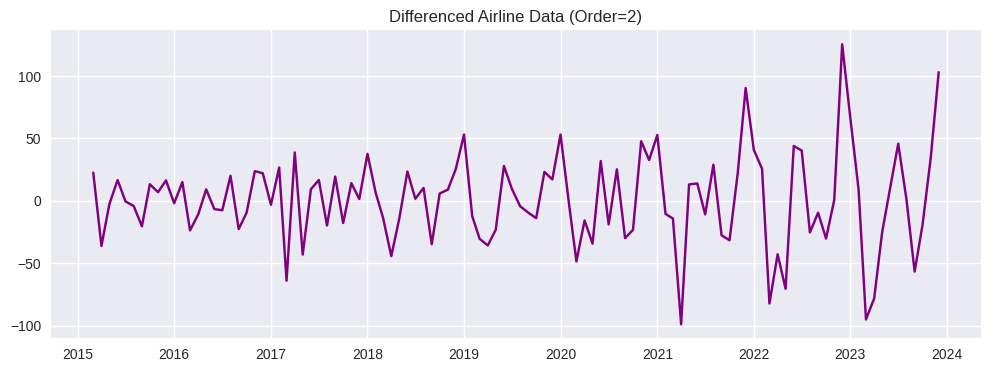

In [6]:
def make_stationary(data, max_diff=3):
    working_data = data.copy()
    diff_order = 0
    for i in range(max_diff + 1):
        if adfuller(working_data.dropna())[1] <= 0.05:
            print(f"Stationary at d={diff_order}")
            return working_data, diff_order
        diff_order += 1
        working_data = working_data.diff()
    return working_data, diff_order

# Apply to airline data
airline_diff, d_order = make_stationary(airline_df["passengers"])

plt.figure(figsize=(12, 4))
plt.plot(airline_diff, color="purple")
plt.title(f"Differenced Airline Data (Order={d_order})")
plt.show()

## 📉 ACF and PACF Analysis

### ELI10
These charts show how much today's value depends on yesterday, or the day before. It's like finding a echo in the data.

**What we are doing:** Plotting Autocorrelation (ACF) and Partial Autocorrelation (PACF).
**Why:** ACF helps pick the 'q' part and PACF helps pick the 'p' part of ARIMA.
**Result:** Insights into the model's structure.

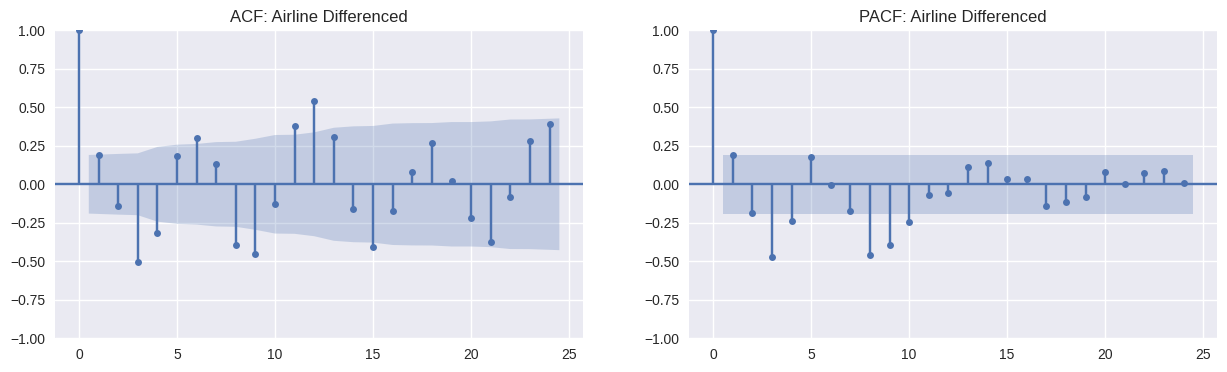

In [7]:
def plot_acf_pacf(data, title, lags=24):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(data.dropna(), ax=axes[0], lags=lags, title=f"ACF: {title}")
    plot_pacf(data.dropna(), ax=axes[1], lags=lags, title=f"PACF: {title}")
    plt.show()

plot_acf_pacf(airline_diff, "Airline Differenced")

## 🤖 ARIMA Modeling

### ELI10
ARIMA is a smart formula that uses past patterns to predict the future. We can find the best settings (p, d, q) by trying many combinations.

**What we are doing:** Running `auto_arima` to find the best non-seasonal parameters.
**Why:** It saves time and prevents human error in picking parameters.
**Result:** An optimized ARIMA model.

In [8]:
# Automatic selection
auto_model = auto_arima(airline_df["passengers"], start_p=0, start_q=0, max_p=5, max_q=5,
                        seasonal=False, stepwise=True, trace=True, error_action='ignore')

# Build final ARIMA
arima_model = ARIMA(airline_df["passengers"], order=auto_model.order).fit()
print(arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1098.633, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1056.594, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1052.441, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1102.326, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1045.691, Time=0.46 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1025.606, Time=0.94 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1029.402, Time=0.34 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1023.682, Time=0.57 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1023.076, Time=0.38 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=1022.146, Time=0.52 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : AIC=1023.885, Time=0.16 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=1024.106, Time=0.33 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=1021.907, Time=0.42 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=975.751, Time=0.66 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             passengers   No. Observations:                  108
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -489.855
Date:                Sat, 18 Apr 2026   AIC                            995.711
Time:                        06:29:04   BIC                           1017.093
Sample:                    01-01-2015   HQIC                          1004.379
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5459      0.140     11.037      0.000       1.271       1.820
ar.L2         -1.2678      0.207     -6.118      0.000      -1.674      -0.862
ar.L3         -0.0250      0.232     -0.108      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 🌦 SARIMA Modeling

### ELI10
SARIMA is just ARIMA but with a "Seasonal" memory. It remembers that every December (for example) is different from every July.

**What we are doing:** Adding seasonal components (P, D, Q, s).
**Why:** Our airline data has strong yearly cycles.
**Result:** A much more accurate model for seasonal data.

In [9]:
sarima_auto = auto_arima(airline_df["passengers"], start_p=0, start_q=0, max_p=3, max_q=3,
                         seasonal=True, m=12, start_P=0, start_Q=0, max_P=2, max_Q=2,
                         stepwise=True, trace=True, error_action='ignore')

sarima_model = SARIMAX(airline_df["passengers"], order=sarima_auto.order,
                       seasonal_order=sarima_auto.seasonal_order).fit(disp=False)
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=835.294, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=831.642, Time=0.24 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=831.702, Time=0.40 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=829.687, Time=0.11 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=831.659, Time=0.68 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=2.07 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=831.677, Time=0.07 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=831.673, Time=0.08 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=829.768, Time=0.07 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=832.655, Time=0.21 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : AIC=828.839, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12] intercept   : AIC=830.834, Time=0.35 sec
 ARIMA(1,1,0)(0,1,1)[12] intercept   : AIC=830.836, Time=0.31 sec
 ARIMA(1,1,0)(1,1,1)[12] intercept   : AIC=inf, Time=1.06 sec
 ARIMA(0,1,0)(0,1,0)[12] intercept   : AI

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 🩺 Residual Diagnostics

### ELI10
After the model is done, we check its mistakes (residuals). If the mistakes look like random "white noise," the model did a great job!

**What we are doing:** Checking the mean, standard deviation, and ACF of errors.
**Why:** Patterns in mistakes mean the model missed something important.
**Result:** Confidence in model quality.

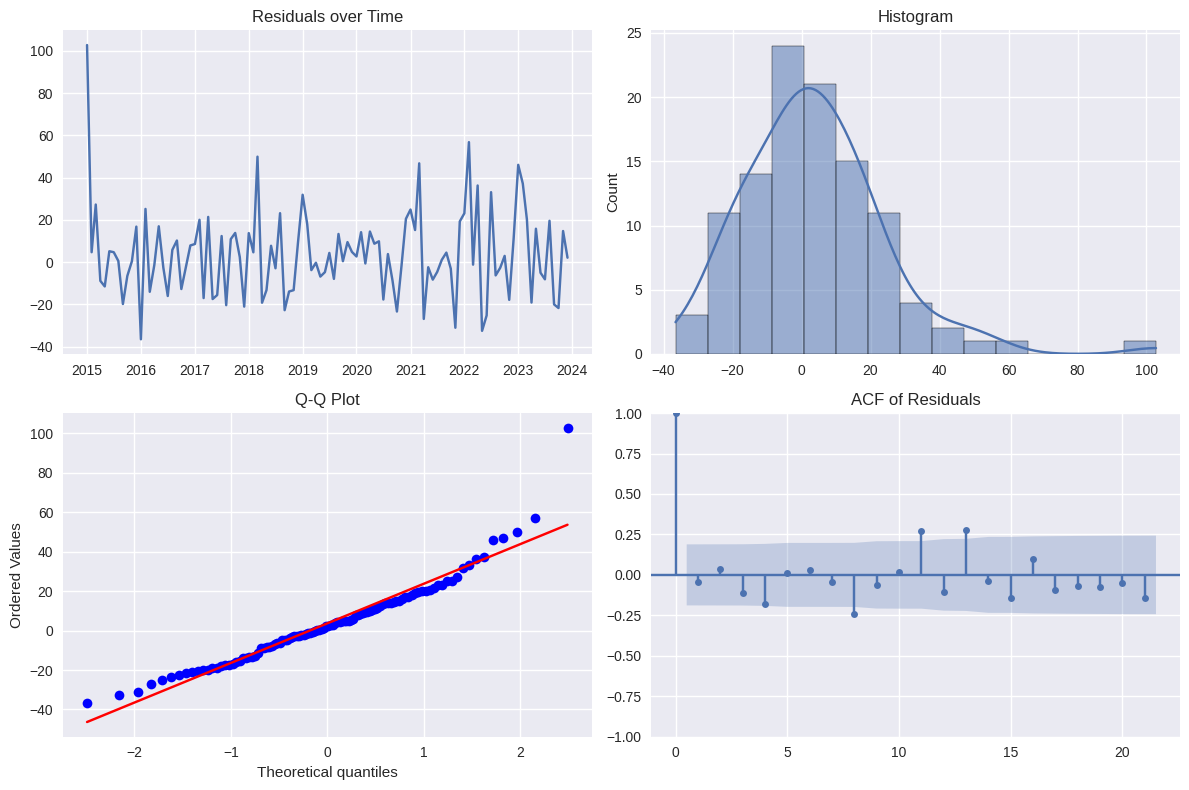

Ljung-Box p-value: 0.2164 (Above 0.05 is good!)


In [10]:
def analyze_residuals(model, title):
    residuals = model.resid
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].plot(residuals); axes[0,0].set_title("Residuals over Time")
    sns.histplot(residuals, kde=True, ax=axes[0,1]); axes[0,1].set_title("Histogram")
    stats.probplot(residuals, dist="norm", plot=axes[1,0]); axes[1,0].set_title("Q-Q Plot")
    plot_acf(residuals, ax=axes[1,1], title="ACF of Residuals")
    plt.tight_layout(); plt.show()

    lb_p = acorr_ljungbox(residuals, lags=[10], return_df=True).lb_pvalue.values[0]
    print(f"Ljung-Box p-value: {lb_p:.4f} (Above 0.05 is good!)")

analyze_residuals(sarima_model, "SARIMA Residuals")

## 📊 Model Comparison

### ELI10
We compare ARIMA vs SARIMA to see which one was better at guessing the numbers. Usually, SARIMA wins for this data.

**What we are doing:** Calculating MAE, RMSE, and AIC.
**Why:** Numbers don't lie. Smaller errors mean a better model.
**Result:** A leaderboard of models.

In [11]:
def get_metrics(model, data, name):
    fitted = model.fittedvalues
    mae = mean_absolute_error(data, fitted)
    rmse = np.sqrt(mean_squared_error(data, fitted))
    return {"Model": name, "MAE": mae, "RMSE": rmse, "AIC": model.aic}

comparison = pd.DataFrame([get_metrics(arima_model, airline_df["passengers"], "ARIMA"),
                            get_metrics(sarima_model, airline_df["passengers"], "SARIMA")])
display(comparison)

,Model,MAE,RMSE,AIC
0,ARIMA,19.707515,25.207192,995.710525
1,SARIMA,15.138121,20.806865,831.673015


## 🔮 Forecasting with Confidence Intervals

### ELI10
Now we look into the future! Because the future is uncertain, we provide a "safe range" (Confidence Interval) where we think the value will be.

**What we are doing:** Predicting the next 12 months.
**Why:** This is the actual goal of the business.
**Result:** A chart showing the forecast and the shaded uncertainty zone.

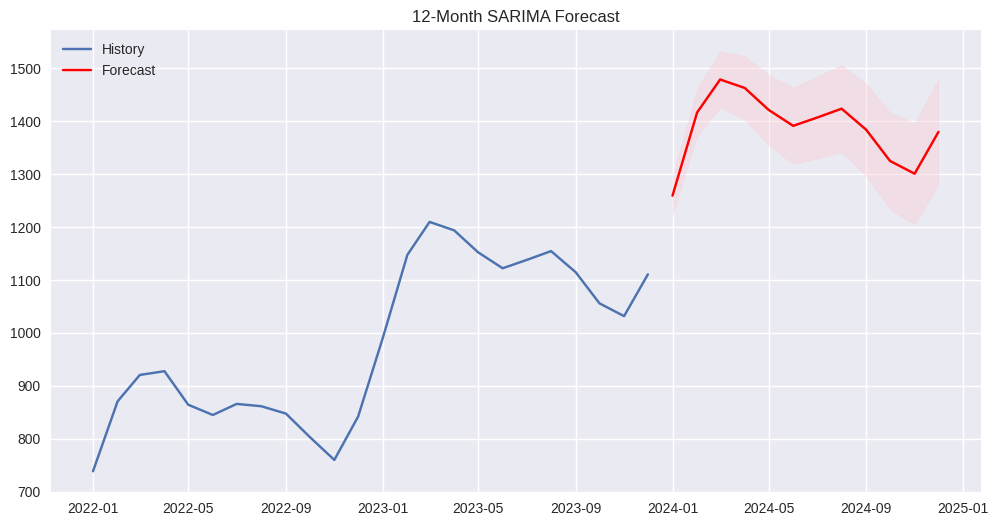

In [12]:
steps = 12
forecast_obj = sarima_model.get_forecast(steps=steps)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(airline_df["passengers"].iloc[-24:], label="History")
plt.plot(forecast_mean, color="red", label="Forecast")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title("12-Month SARIMA Forecast")
plt.legend(); plt.show()

## 🚶 Walk-Forward Validation

### ELI10
This is like a dress rehearsal. We pretend we are in the past and see how well we would have predicted the last 12 months.

**What we are doing:** Retraining the model at every step to predict one point ahead.
**Why:** It's the most realistic way to measure real-world performance.
**Result:** A very honest error score.

In [13]:
def walk_forward_validation(data, order, s_order, n_test=12):
    history = list(data[:-n_test])
    predictions = []
    for i in range(n_test):
        model = SARIMAX(history, order=order, seasonal_order=s_order).fit(disp=False)
        predictions.append(model.forecast()[0])
        history.append(data[-(n_test-i)])

    rmse = np.sqrt(mean_squared_error(data[-n_test:], predictions))
    return predictions, rmse

preds, wf_rmse = walk_forward_validation(airline_df["passengers"].values, sarima_auto.order, sarima_auto.seasonal_order)
print(f"Walk-Forward RMSE: {wf_rmse:.4f}")

Walk-Forward RMSE: 23.3760


## 💼 Business Insights & ⚠️ Risk Assessment

### ELI10
Numbers mean nothing without a plan. We look at the growth and the risk of being wrong to give advice to the boss.

**What we are doing:** Calculating growth rates and relative uncertainty.
**Why:** To decide if we should hire more staff or buy more planes.
**Result:** Business recommendations.

In [14]:
current = airline_df["passengers"].iloc[-1]
future = forecast_mean.iloc[-1]
growth = ((future - current) / current) * 100

# Risk Calculation
interval_width = (conf_int.iloc[:, 1] - conf_int.iloc[:, 0]).mean()
rel_uncertainty = (interval_width / forecast_mean.mean()) * 100
risk_level = "Low" if rel_uncertainty < 10 else "Moderate" if rel_uncertainty < 20 else "High"

print(f"--- Business Summary ---")
print(f"12-Month Growth: {growth:.2f}%")
print(f"Average Uncertainty: {rel_uncertainty:.2f}%")
print(f"Risk Level: {risk_level}")
print(f"Recommendation: {'Aggressive Expansion' if growth > 5 and risk_level != 'High' else 'Cautionary Monitoring'}")

--- Business Summary ---
12-Month Growth: 24.22%
Average Uncertainty: 10.43%
Risk Level: Moderate
Recommendation: Aggressive Expansion


## ✅ Verification

We verify that all required outputs were generated successfully.

In [15]:
print("Checking Outputs...")
assert 'airline_df' in globals(), "Dataset missing"
assert 'arima_model' in globals(), "ARIMA missing"
assert 'sarima_model' in globals(), "SARIMA missing"
assert 'forecast_mean' in globals(), "Forecast missing"
print("Verification Successful: All components present.")

Checking Outputs...
Verification Successful: All components present.


## 🛠 Troubleshooting

*   **pmdarima errors:** Ensure `!pip install` ran at the top.
*   **Convergence Warning:** This happens when the math is hard. Usually solved by simplifying the model (lower p, q).
*   **Index Errors:** Ensure your DataFrame index has a frequency (e.g., `MS` for Monthly Start).

## 📚 Key Takeaways
*   **ARIMA** handles trend; **SARIMA** handles trend AND seasonality.
*   **ADF Test** is mandatory before modeling.
*   **Residuals** must be random (White Noise).
*   **Walk-Forward Validation** is the gold standard for testing.

## 🧠 Key Concepts Summary
*   **p (AR):** Lags (yesterday).
*   **d (I):** Differencing (change).
*   **q (MA):** Error memory.
*   **s:** Seasonal period (12 for months).

## 🎓 What You Learned
You built a professional-grade forecasting pipeline that handles raw data, tests it, finds the best model, validates it honestly, and provides actionable business risk scores.

## 🌍 Real-World Importance
These models drive logistics for Amazon, flight pricing for airlines, and stock levels for retailers every single day.

## 🏁 Conclusion
This completes Lab 48. You now have the skills to apply classical statistical forecasting to any time series dataset.